In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [4]:
experiment_dir = Path("/dcs/large/u1508153/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

results_df

mean_cost    var_cost  \
uuid                                 replication                          
37623108-d6bc-4aec-98d6-e84dcbe6056b 0            37.832657  902.310685   
                                     1            33.028892  759.106951   
                                     2            37.678419  863.177572   
                                     3            34.849218  762.337428   
                                     4            36.012512  536.245886   
...                                                     ...         ...   
b7be2ed4-1741-44aa-bf48-078af6e87bdc 195          43.050357  626.859457   
                                     196          40.266921  655.494471   
                                     197          51.478847  789.461804   
                                     198          37.472319  544.333850   
                                     199          38.180883  471.200929   

                                                   solution  dgp_time  \
uuid                                 replication                        
37623108-d6bc-4aec-98d6-e84dcbe6056b 0            29.924193  0.000384   
                                     1            29.923386  0.000295   
                                     2            31.052841  0.000291   
                                     3            33.474855  0.000433   
                                     4            34.460232  0.000240   
...                                                     ...       ...   
b7be2ed4-1741-44aa-bf48-078af6e87bdc 195          39.308057  0.000219   
                                     196          38.007112  0.000194   
                                     197          40.626707  0.000190   
                                     198          35.363954  0.000188   
                                     199          40.493410  0.000192   

                                                  likelihood_time  \
uuid                                 replication                    
37623108-d6bc-4aec-98d6-e84dcbe6056b 0                   0.000042   
                                     1                   0.000030   
                                     2                   0.000027   
                                     3                   0.000041   
                                     4                   0.000034   
...                                                           ...   
b7be2ed4-1741-44aa-bf48-078af6e87bdc 195                 0.000069   
                                     196                 0.000069   
                                     197                 0.000067   
                                     198                 0.000069   
                                     199                 0.000068   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
37623108-d6bc-4aec-98d6-e84dcbe6056b 0                  0.000145    0.031552   
                                     1                  0.000131    0.028495   
                                     2                  0.000120    0.082320   
                                     3                  0.000167    0.222560   
                                     4                  0.000120    0.035114   
...                                                          ...         ...   
b7be2ed4-1741-44aa-bf48-078af6e87bdc 195                0.000080    0.613593   
                                     196                0.000073    0.638594   
                                     197                0.000072    0.650006   
                                     198                0.000074    0.600493   
                                     199                0.000072    0.660933   

                                                  setup_time    algorithm  \
uuid                                 replication                            
37623108-d6bc-4aec-98d6-e84dcbe

In [5]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                     mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.1     bayes     normal_gamma 10                    10                            NaN   
                                                  20                    20                            NaN   
                                                  30                    30                            NaN   
                   0.2     bayes     normal_gamma 10                    10                            NaN   
                                                  20                    20                            NaN   
...                                                                                                   ...   
our_kl_bdro normal 2.5     bayes     normal_gamma 1                     2500                    48.698745   
                   3.0     bayes     normal_gamma 1                     100                     43.749319   
                                                                        400                     47.764085   
                                                                        900                     48.701124   
                                                                        2500                    50.194862   

                                                                                                           \
                                                                                                      var   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.1     bayes     normal_gamma 10                    10                            NaN   
                                                  20                    20                            NaN   
                                                  30                    30                            NaN   
                   0.2     bayes     normal_gamma 10                    10                            NaN   
                                                  20                    20                            NaN   
...                                                                                                   ...   
our_kl_bdro normal 2.5     bayes     normal_gamma 1                     2500                    69.211011   
                   3.0     bayes     normal_gamma 1                     100                     68.601458   
                                                                        400                     83.879121   
                                                                        900                     75.958743   
                                                                        2500                    79.263708   

                                                                                                  var_cost  \
                                                                                                      mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples               
kl_bdro     normal 0.1     bayes     normal_gamma 10                    10                             NaN   
                                                  20                    20                             NaN   
                                                  30                    30                             NaN   
                   0.2     bayes     normal_gamma 10                    10                             NaN   
                                                  20                    20                             NaN   
...                                                                                                    ...   
our_kl_bdro normal 2.5     bayes     normal_gamma 1 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


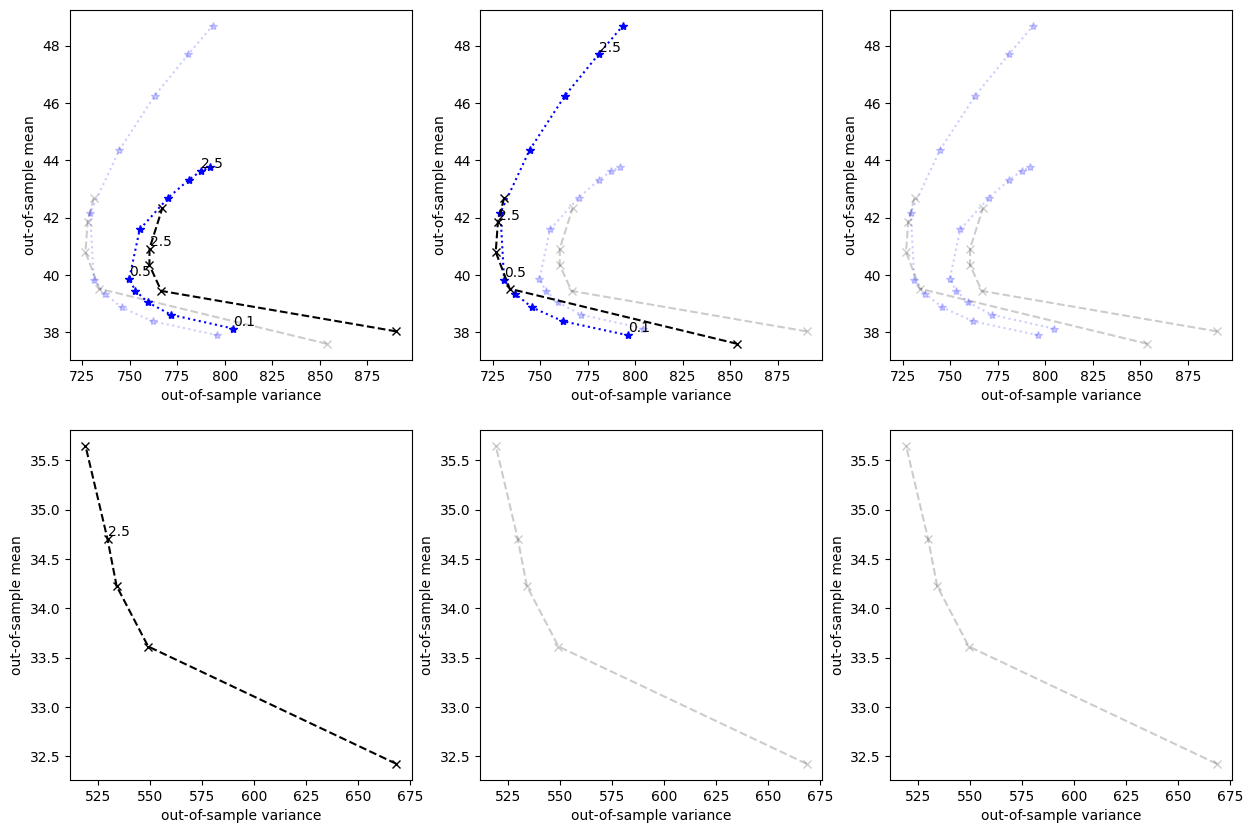

In [9]:
from mis_dro.plot import mean_variance_plot, algorithm_style

from enum import StrEnum

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

compare_col="algorithm"
gb_col="dgp"
ncols=2
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES_SQRT = [10, 30, 100]

nrows = 2
ncols = len(TOTAL_SAMPLES_SQRT)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))

for j, n_total_samples_sqrt in enumerate(TOTAL_SAMPLES_SQRT):
    df = agg_df.loc[(
        (likelihood_sr == n_total_samples_sqrt) & (posterior_sr == n_total_samples_sqrt)
        | (likelihood_sr == n_total_samples_sqrt ** 2) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)
    for k in range(len(TOTAL_SAMPLES_SQRT)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                mean_variance_plot(axes[i, k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled)
            

fig.show()

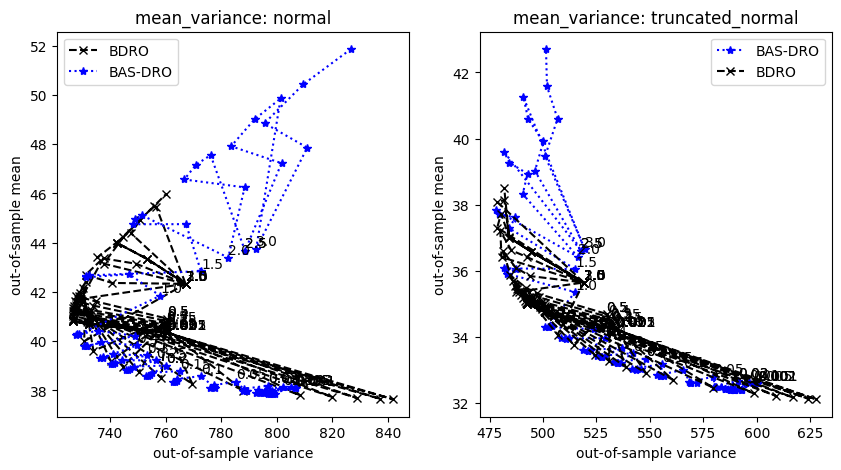

In [ ]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
fig.show()

## Solve time

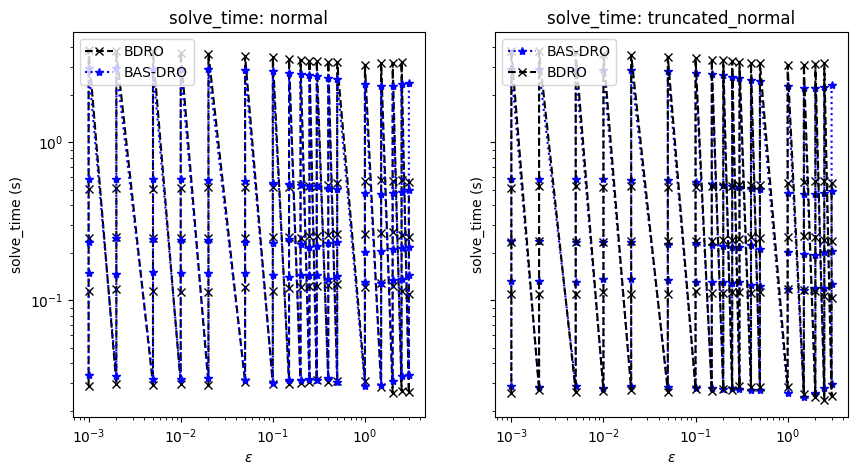

In [ ]:
fig, axes = flexible_figure(agg_df, "solve_time", compare_col="algorithm", gb_col="dgp", sharex=True, sharey=True, ncols=2)
fig.show()

In [ ]:
# what is the constant G?
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = 10
G_constant = []
posterior_expected_kl = []
prior_expected_kl = []
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.mean(G_constant), np.var(G_constant)

(0.08827544585267265, 1.925929944387236e-34)

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.16462497724528255, 0.012848186395172448)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.78569035285864, 0.0)

In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 794.3194647834051, 17.727414116711756)

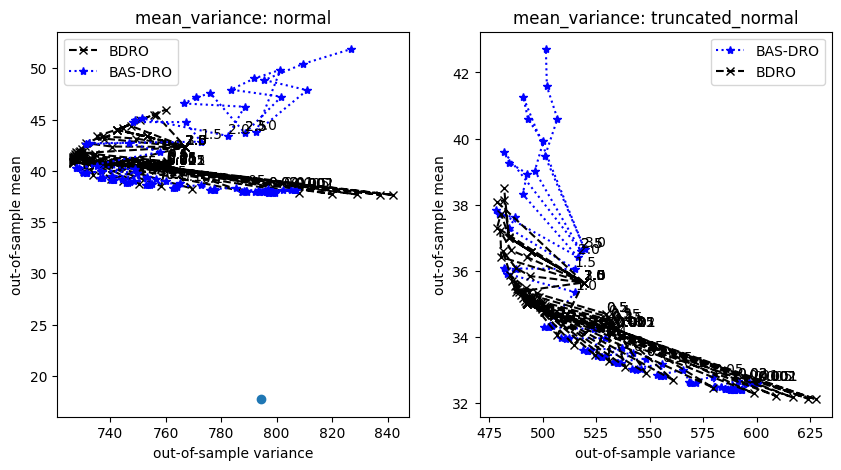

In [ ]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
axes[0].scatter(mean_of_variances, var_of_means)
fig.show()

epsilon | mean squared error to opt | std of mean squared error
----------
0.1 | 